## Artificial Immune System (AIS) for Structure Damage Classification

This notebook outlines a general approach to applying Artificial Immune Systems for classifying structural damage. The core idea is often to train the system on 'healthy' data and then detect 'damage' as anomalous patterns that deviate significantly from the learned 'self' patterns.

In [1]:
# Step 1: Data Loading
# Please replace this with your actual data loading mechanism.
# The data should ideally consist of features extracted from structural monitoring (e.g., vibration data, strain, acoustic emissions).
# You will need both 'healthy' and 'damaged' data for training and testing.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Placeholder for your dataset
# Example: Generate some synthetic data for demonstration purposes
# 'Healthy' data could be clustered around a mean
np.random.seed(42)
healthy_data = np.random.randn(500, 2) * 0.5 + np.array([0, 0])
healthy_labels = np.zeros(500) # 0 for healthy

# 'Damaged' data could be outliers or from a different distribution
damaged_data = np.random.randn(50, 2) * 0.8 + np.array([3, 3])
damaged_labels = np.ones(50) # 1 for damaged

X = np.vstack((healthy_data, damaged_data))
y = np.hstack((healthy_labels, damaged_labels))

print(f"Shape of features (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")

# Typically, you would split your data into training and testing sets.
# For AIS, often a separate 'self' set (healthy training data) is used to generate detectors.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Separate healthy data for 'self' set (for negative selection based algorithms)
X_self = X_train[y_train == 0]

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of X_self (healthy training data): {X_self.shape}")


Shape of features (X): (550, 2)
Shape of labels (y): (550,)

Shape of X_train: (385, 2)
Shape of X_test: (165, 2)
Shape of X_self (healthy training data): (350, 2)


### Step 2: Data Preprocessing

This step typically involves scaling, normalization, or feature engineering to make the data suitable for the AIS algorithm. For many distance-based AIS algorithms, features should be on a similar scale.

In [2]:
# Apply a scaler to normalize features
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_self_scaled = scaler.transform(X_self)

print("Data scaled successfully.")


Data scaled successfully.


### Step 3: Artificial Immune System (AIS) Algorithm Implementation

There are various AIS algorithms. A common approach for anomaly detection (like damage classification) is the Negative Selection Algorithm (NSA). Here, we'll outline a conceptual NSA where 'detectors' are generated to recognize 'non-self' (damage) based on not recognizing 'self' (healthy data).

In [3]:
# Conceptual Negative Selection Algorithm (NSA) implementation

class NegativeSelectionClassifier:
    def __init__(self, num_detectors=100, radius=0.1, threshold=0.9):
        self.num_detectors = num_detectors
        self.radius = radius
        self.threshold = threshold
        self.detectors = []

    def fit(self, X_self):
        # Generate random detectors until 'num_detectors' are found that do not match any 'self' cell
        # This is a very simplified version; real NSA is more complex with maturation and affinity calculation.

        X_min = np.min(X_self, axis=0)
        X_max = np.max(X_self, axis=0)

        while len(self.detectors) < self.num_detectors:
            # Generate a random detector within the data range
            detector = X_min + (X_max - X_min) * np.random.rand(X_self.shape[1])

            # Check if this detector 'matches' any 'self' cell (i.e., is too close to 'self')
            # A detector is considered valid if it does NOT match any self cell.
            is_valid_detector = True
            for self_cell in X_self:
                distance = np.linalg.norm(detector - self_cell)
                if distance < self.radius: # If it's too close to a self-cell, it's not a valid detector
                    is_valid_detector = False
                    break

            if is_valid_detector:
                self.detectors.append(detector)

        self.detectors = np.array(self.detectors)
        print(f"Generated {len(self.detectors)} detectors.")

    def predict(self, X):
        predictions = []
        for x_instance in X:
            # Check if the instance is recognized by any detector
            # If it's recognized by a detector, it's considered 'non-self' or 'anomaly' (damage)
            num_matches = 0
            for detector in self.detectors:
                distance = np.linalg.norm(x_instance - detector)
                if distance < self.radius: # If the instance falls within a detector's radius
                    num_matches += 1

            # Classify as damaged (1) if a sufficient number of detectors recognize it, else healthy (0)
            if num_matches > 0: # Simple thresholding: if any detector matches, it's damage
                predictions.append(1) # Damaged
            else:
                predictions.append(0) # Healthy

        return np.array(predictions)

# Initialize and train the conceptual AIS classifier
ais_classifier = NegativeSelectionClassifier(num_detectors=50, radius=0.2)
ais_classifier.fit(X_self_scaled)

# Make predictions on the test set
y_pred = ais_classifier.predict(X_test_scaled)
print(f"\nSample predictions: {y_pred[:10]}")


Generated 50 detectors.

Sample predictions: [0 0 0 0 0 0 0 0 0 0]


### Step 4: Evaluation

Evaluate the performance of the AIS classifier using appropriate metrics for classification (e.g., accuracy, precision, recall, F1-score, confusion matrix).

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.9091
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Confusion Matrix:
[[150   0]
 [ 15   0]]


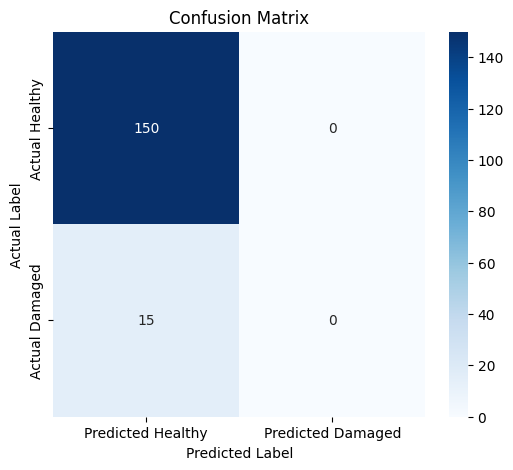

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Healthy', 'Predicted Damaged'],
            yticklabels=['Actual Healthy', 'Actual Damaged'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# You would typically further analyze results, tune parameters, or try different AIS algorithms.
